<a href="https://colab.research.google.com/github/MKSINGH7/Sugarcane-dataset/blob/main/01_dataset_pipeline_standalone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sugarcane Disease Dataset (Assam, Version 2) — Standalone Dataset Pipeline
**Dissertation:** Explainable AI for Deep Learning-Based Plant Disease Detection

This notebook contains ONLY: setup → download → extraction → inspection → analysis → stratified split →
preprocessing → augmentation → DataLoaders → verification. No model, no XAI.

Run cells top to bottom. Nothing about class names or counts is hard-coded: everything is read from the files.

## Cell 1 — Project configuration

In [8]:
import os, sys, json, random, hashlib, zipfile, shutil, warnings
from pathlib import Path
from collections import Counter, defaultdict

CFG = dict(
    SEED=42,
    # ---- storage ---------------------------------------------------------
    USE_DRIVE=False,                         # True -> results + split manifest persist on Google Drive
    DRIVE_DIR="/content/drive/MyDrive/sugarcane_xai",
    LOCAL_DIR=os.environ.get("SUGARCANE_LOCAL_DIR", "/content/sugarcane_xai"),
    DATA_DIR=os.environ.get("SUGARCANE_DATA_DIR", "/content/sugarcane_data"),
    # ---- dataset acquisition ---------------------------------------------
    # Version 2 = DOI 10.17632/x98kpjvxxg.2  (NOTE: the URL ending in /1 is Version 1)
    MENDELEY_ZIP_URL="https://data.mendeley.com/public-api/zip/x98kpjvxxg/download/2",
    MANUAL_ZIP_PATH="/content/Sugarcane Plant Disease Dataset of Assam.zip",
    DATASET_ROOT_OVERRIDE=None,              # set to a folder path if auto-detection picks the wrong folder
    IMAGE_EXTS=(".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"),
    # ---- preprocessing (from synopsis) -----------------------------------
    IMG_SIZE=224,
    BATCH_SIZE=32,
    NUM_WORKERS=2,
    # ---- split -----------------------------------------------------------
    SPLIT=(0.70, 0.15, 0.15),               # train / val / test
    GROUP_REGEX=None,                       # optional regex with ONE capture group -> plant/field id from filename
    USE_EXACT_DUP_GROUPS=True,              # identical files always stay in the same split
    USE_NEAR_DUP_GROUPS=True,               # near-identical (perceptual-hash) images stay together
    NEAR_DUP_HAMMING=4,                     # pHash Hamming distance <= this => "near duplicate" (heuristic)
    USE_WEIGHTED_SAMPLER=False,             # optional; class weights in the loss are the default remedy
)

BASE_DIR = Path(CFG["DRIVE_DIR"] if CFG["USE_DRIVE"] else CFG["LOCAL_DIR"])
DATA_DIR = Path(CFG["DATA_DIR"])
RESULTS = BASE_DIR / "results"
SUBDIRS = ["dataset_analysis", "training", "evaluation", "gradcam_pp", "layercam",
           "layerwise", "comparison", "xai_metrics"]

if CFG["USE_DRIVE"] and "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")

for s in SUBDIRS:
    (RESULTS / s).mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR = RESULTS / "dataset_analysis"

def seed_everything(seed):
    random.seed(seed)
    import numpy as _np
    _np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(CFG["SEED"])

print("Results folder :", RESULTS)
print("Data folder    :", DATA_DIR)

Results folder : /content/sugarcane_xai/results
Data folder    : /content/sugarcane_data


## Cell 2 — GPU verification (informational; the dataset pipeline itself does not need a GPU)

In [9]:
try:
    import torch
    print("PyTorch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("No GPU. Fine for this notebook; for training use Runtime > Change runtime type > T4 GPU.")
except ImportError:
    print("PyTorch not installed here (fine for the analysis/split cells; Cell 13 needs it — it is preinstalled on Colab).")

PyTorch 2.11.0+cpu | CUDA available: False
No GPU. Fine for this notebook; for training use Runtime > Change runtime type > T4 GPU.


## Cell 3 — Package installation
Colab already provides torch, torchvision, numpy, pandas, matplotlib, scikit-learn, opencv, Pillow, tqdm.

In [10]:
%pip install -q "albumentations>=2.0" imagehash requests
# (In a plain .py run, install these yourself.)

## Cell 4 — Imports (torch-free on purpose, so the analysis/split cells run anywhere)

In [11]:
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
import imagehash, requests
Image.MAX_IMAGE_PIXELS = None
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
print("numpy", np.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0


## Cell 5 — Dataset download / access
**Version 2** of "Sugarcane Plant Disease Dataset of Assam" is `https://data.mendeley.com/datasets/x98kpjvxxg/2`.
The URL you gave (`.../1`) is **Version 1**. Below we try the Mendeley public zip endpoint for version 2;
if it fails (Mendeley sometimes blocks scripted downloads), download the zip manually from the /2 page
and either upload it to Colab or put it on Drive, then set `CFG["MANUAL_ZIP_PATH"]`.

In [12]:
def find_existing_zip():
    if CFG["MANUAL_ZIP_PATH"] and Path(CFG["MANUAL_ZIP_PATH"]).exists():
        return Path(CFG["MANUAL_ZIP_PATH"])
    z = DATA_DIR / "sugarcane_assam_v2.zip"
    return z if z.exists() and zipfile.is_zipfile(z) else None

def download_mendeley(url, dest):
    headers = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) Colab-Research"}
    with requests.get(url, stream=True, timeout=60, headers=headers, allow_redirects=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(dest, "wb") as f, tqdm(total=total or None, unit="B", unit_scale=True, desc="download") as bar:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk); bar.update(len(chunk))

def load_dataset_zip():
    """Return path to a valid dataset zip (existing, manual, or freshly downloaded)."""
    z = find_existing_zip()
    if z:
        print("Using existing zip:", z); return z
    dest = DATA_DIR / "sugarcane_assam_v2.zip"
    try:
        print("Downloading from:", CFG["MENDELEY_ZIP_URL"])
        download_mendeley(CFG["MENDELEY_ZIP_URL"], dest)
        if not zipfile.is_zipfile(dest):
            raise RuntimeError("Downloaded file is not a valid zip archive.")
        return dest
    except Exception as e:
        if dest.exists(): dest.unlink()
        raise RuntimeError(
            f"Automatic download failed: {e}\n\n"
            "MANUAL FALLBACK:\n"
            " 1. Open https://data.mendeley.com/datasets/x98kpjvxxg/2 and click 'Download All'.\n"
            " 2. Upload the zip to Colab (Files panel) or Google Drive.\n"
            " 3. Set CFG['MANUAL_ZIP_PATH'] = '<path to zip>' in Cell 1 and re-run from Cell 5.\n"
            " (If you already extracted the data, put the folder under DATA_DIR and skip to Cell 7.)")

# Skip download if the data folder already has images (re-run safe)
already = any(p.suffix.lower() in CFG["IMAGE_EXTS"] for p in DATA_DIR.rglob("*") if p.is_file())
ZIP_PATH = None if already else load_dataset_zip()
print("Data already extracted." if already else f"Zip ready: {ZIP_PATH} ({ZIP_PATH.stat().st_size/1e6:.1f} MB)")

Using existing zip: /content/Sugarcane Plant Disease Dataset of Assam.zip
Zip ready: /content/Sugarcane Plant Disease Dataset of Assam.zip (316.7 MB)


## Cell 6 — Extraction (handles zips nested inside zips, which Mendeley uploads often contain)

In [14]:
def extract_all(zip_path, out_dir):
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(out_dir)
    changed = True
    while changed:                                   # extract nested zips
        changed = False
        for p in list(Path(out_dir).rglob("*.zip")):
            if p == Path(zip_path): continue
            target = p.parent / p.stem
            try:
                with zipfile.ZipFile(p) as z:
                    z.extractall(target)
                p.rename(p.with_suffix(".zip.done")); changed = True
            except zipfile.BadZipFile:
                p.rename(p.with_suffix(".zip.bad")); print("Bad nested zip:", p)
    others = [p for p in Path(out_dir).rglob("*") if p.suffix.lower() in (".rar", ".7z", ".tar", ".gz")]
    if others:
        print("WARNING: archives not auto-extracted (extract manually):", others[:5])

if not already:
    extract_all(ZIP_PATH, DATA_DIR)
n_img = sum(1 for p in DATA_DIR.rglob("*") if p.is_file() and p.suffix.lower() in CFG["IMAGE_EXTS"])
print(f"Image files found under {DATA_DIR}: {n_img}")
assert n_img > 0, "No images found. Check the zip / CFG['IMAGE_EXTS']."

Image files found under /content/sugarcane_data: 5769


## Cell 7 — Dataset structure inspection (locate root, identify class folders — nothing hard-coded)

In [15]:
SPLIT_NAMES = {"train", "training", "val", "valid", "validation", "test", "testing"}
IGNORE_PARTS = {"__MACOSX", ".ipynb_checkpoints"}

def is_img(p): return p.is_file() and p.suffix.lower() in CFG["IMAGE_EXTS"] and not (set(p.parts) & IGNORE_PARTS) and not p.name.startswith("._")

def find_dataset_root(base):
    imgs = [p for p in base.rglob("*") if is_img(p)]
    best = None
    dirs = {base} | {a for p in imgs for a in p.parents if base in a.parents or a == base}
    for d in dirs:
        groups = Counter(p.relative_to(d).parts[0] for p in imgs if d in p.parents and len(p.relative_to(d).parts) > 1)
        if len(groups) >= 2:
            key = (sum(groups.values()), -len(d.parts))
            if best is None or key > best[0]:
                best = (key, d, groups)
    if best is None:
        raise RuntimeError("Could not find >=2 class sub-folders containing images. Set CFG['DATASET_ROOT_OVERRIDE'].")
    return best[1], best[2]

def print_tree(root, max_depth=3):
    def rec(d, depth, prefix=""):
        subs = sorted([x for x in d.iterdir() if x.is_dir() and x.name not in IGNORE_PARTS])
        nimg = sum(1 for x in d.iterdir() if is_img(x))
        print(f"{prefix}{d.name}/  [{nimg} images directly inside]")
        if depth < max_depth:
            for s in subs[:40]: rec(s, depth + 1, prefix + "    ")
    rec(root, 0)

if CFG["DATASET_ROOT_OVERRIDE"]:
    DATASET_ROOT = Path(CFG["DATASET_ROOT_OVERRIDE"]); top_groups = None
else:
    DATASET_ROOT, top_groups = find_dataset_root(DATA_DIR)
print("Detected dataset root:", DATASET_ROOT, "\n")
print_tree(DATASET_ROOT)

top_names = {d.name for d in DATASET_ROOT.iterdir() if d.is_dir()}
PRESPLIT = bool(top_names) and {n.lower() for n in top_names} <= SPLIT_NAMES
if PRESPLIT:
    print("\n!! The dataset ships pre-split folders", sorted(top_names),
          "\n   They will be MERGED per class and re-split by this notebook (original split kept in column 'orig_split').")

Detected dataset root: /content/sugarcane_data/Sugarcane Plant Disease Dataset of Assam 

Sugarcane Plant Disease Dataset of Assam/  [0 images directly inside]
    Grassy Shoot/  [611 images directly inside]
    Healthy/  [679 images directly inside]
    Mosaic/  [611 images directly inside]
    Pokkah Boeng/  [611 images directly inside]
    Red Leaf Spot/  [611 images directly inside]
    Red Rot/  [678 images directly inside]
    Ring Spot/  [679 images directly inside]
    Wilt/  [611 images directly inside]
    Yellow Leaf Disease/  [678 images directly inside]


## Cell 8 — Dataset statistics (manifest, class names, counts, imbalance, chart)

Total images     : 5769
Number of classes: 9
Class names      : ['Grassy Shoot', 'Healthy', 'Mosaic', 'Pokkah Boeng', 'Red Leaf Spot', 'Red Rot', 'Ring Spot', 'Wilt', 'Yellow Leaf Disease']

                      images  percent
class                               
Grassy Shoot            611    10.59
Healthy                 679    11.77
Mosaic                  611    10.59
Pokkah Boeng            611    10.59
Red Leaf Spot           611    10.59
Red Rot                 678    11.75
Ring Spot               679    11.77
Wilt                    611    10.59
Yellow Leaf Disease     678    11.75

Imbalance ratio (largest/smallest class): 1.11  (Healthy vs Grassy Shoot)
Rule of thumb: <1.5 balanced; 1.5-3 mild; >3 notable -> use class-weighted loss + macro-F1 (not accuracy only).

File extensions  : {'.jpeg': 5377, '.jpg': 392}


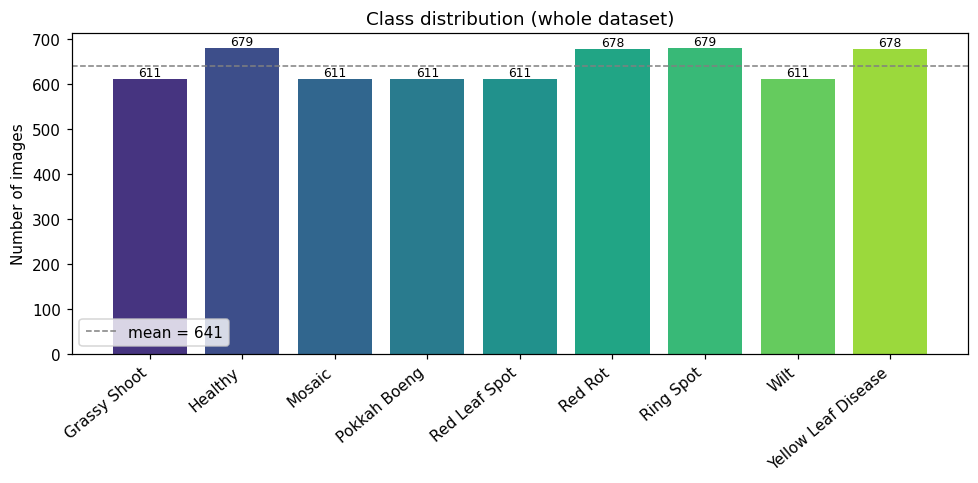


Synopsis expects 9 classes (8 disease + 1 healthy) -> MATCH
A related data paper reports 5,769 images (not verified against the V2 files) -> found 5769
Please identify which class is 'healthy' from the printed names above; the code does not assume any name.


In [16]:
def build_manifest(root):
    rows = []
    for p in sorted(root.rglob("*")):
        if not is_img(p): continue
        parts = p.relative_to(root).parts
        if len(parts) < 2: continue                       # image sitting directly in root: no class
        if PRESPLIT:
            if len(parts) < 3: continue
            rows.append((str(p.relative_to(root)), parts[1], parts[0]))
        else:
            rows.append((str(p.relative_to(root)), parts[0], ""))
    return pd.DataFrame(rows, columns=["path", "class", "orig_split"])

def analyze_dataset(df):
    classes = sorted(df["class"].unique())
    counts = df["class"].value_counts().reindex(classes)
    print(f"Total images     : {len(df)}")
    print(f"Number of classes: {len(classes)}")
    print("Class names      :", classes)
    tab = pd.DataFrame({"images": counts, "percent": (100 * counts / len(df)).round(2)})
    print("\n", tab.to_string())
    ratio = counts.max() / counts.min()
    print(f"\nImbalance ratio (largest/smallest class): {ratio:.2f}  "
          f"({counts.idxmax()} vs {counts.idxmin()})")
    print("Rule of thumb: <1.5 balanced; 1.5-3 mild; >3 notable -> use class-weighted loss + macro-F1 (not accuracy only).")
    print("\nFile extensions  :", dict(Counter(Path(p).suffix.lower() for p in df["path"])))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.bar(range(len(classes)), counts.values, color=plt.cm.viridis(np.linspace(0.15, 0.85, len(classes))))
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=40, ha="right")
    ax.set_ylabel("Number of images"); ax.set_title("Class distribution (whole dataset)")
    for b, v in zip(bars, counts.values): ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom", fontsize=8)
    ax.axhline(counts.mean(), ls="--", c="gray", lw=1, label=f"mean = {counts.mean():.0f}"); ax.legend()
    plt.tight_layout(); plt.savefig(ANALYSIS_DIR / "class_distribution.png"); plt.show()
    return classes, tab

manifest = build_manifest(DATASET_ROOT)
CLASSES, class_table = analyze_dataset(manifest)
class_table.to_csv(ANALYSIS_DIR / "class_counts.csv")

# Compare with what the synopsis / related data paper say (comparison only — files are the source of truth)
print("\nSynopsis expects 9 classes (8 disease + 1 healthy) ->", "MATCH" if len(CLASSES) == 9 else f"MISMATCH: found {len(CLASSES)}")
print("A related data paper reports 5,769 images (not verified against the V2 files) ->", f"found {len(manifest)}")
print("Please identify which class is 'healthy' from the printed names above; the code does not assume any name.")

## Cell 9 — Sample visualization (one row per class)

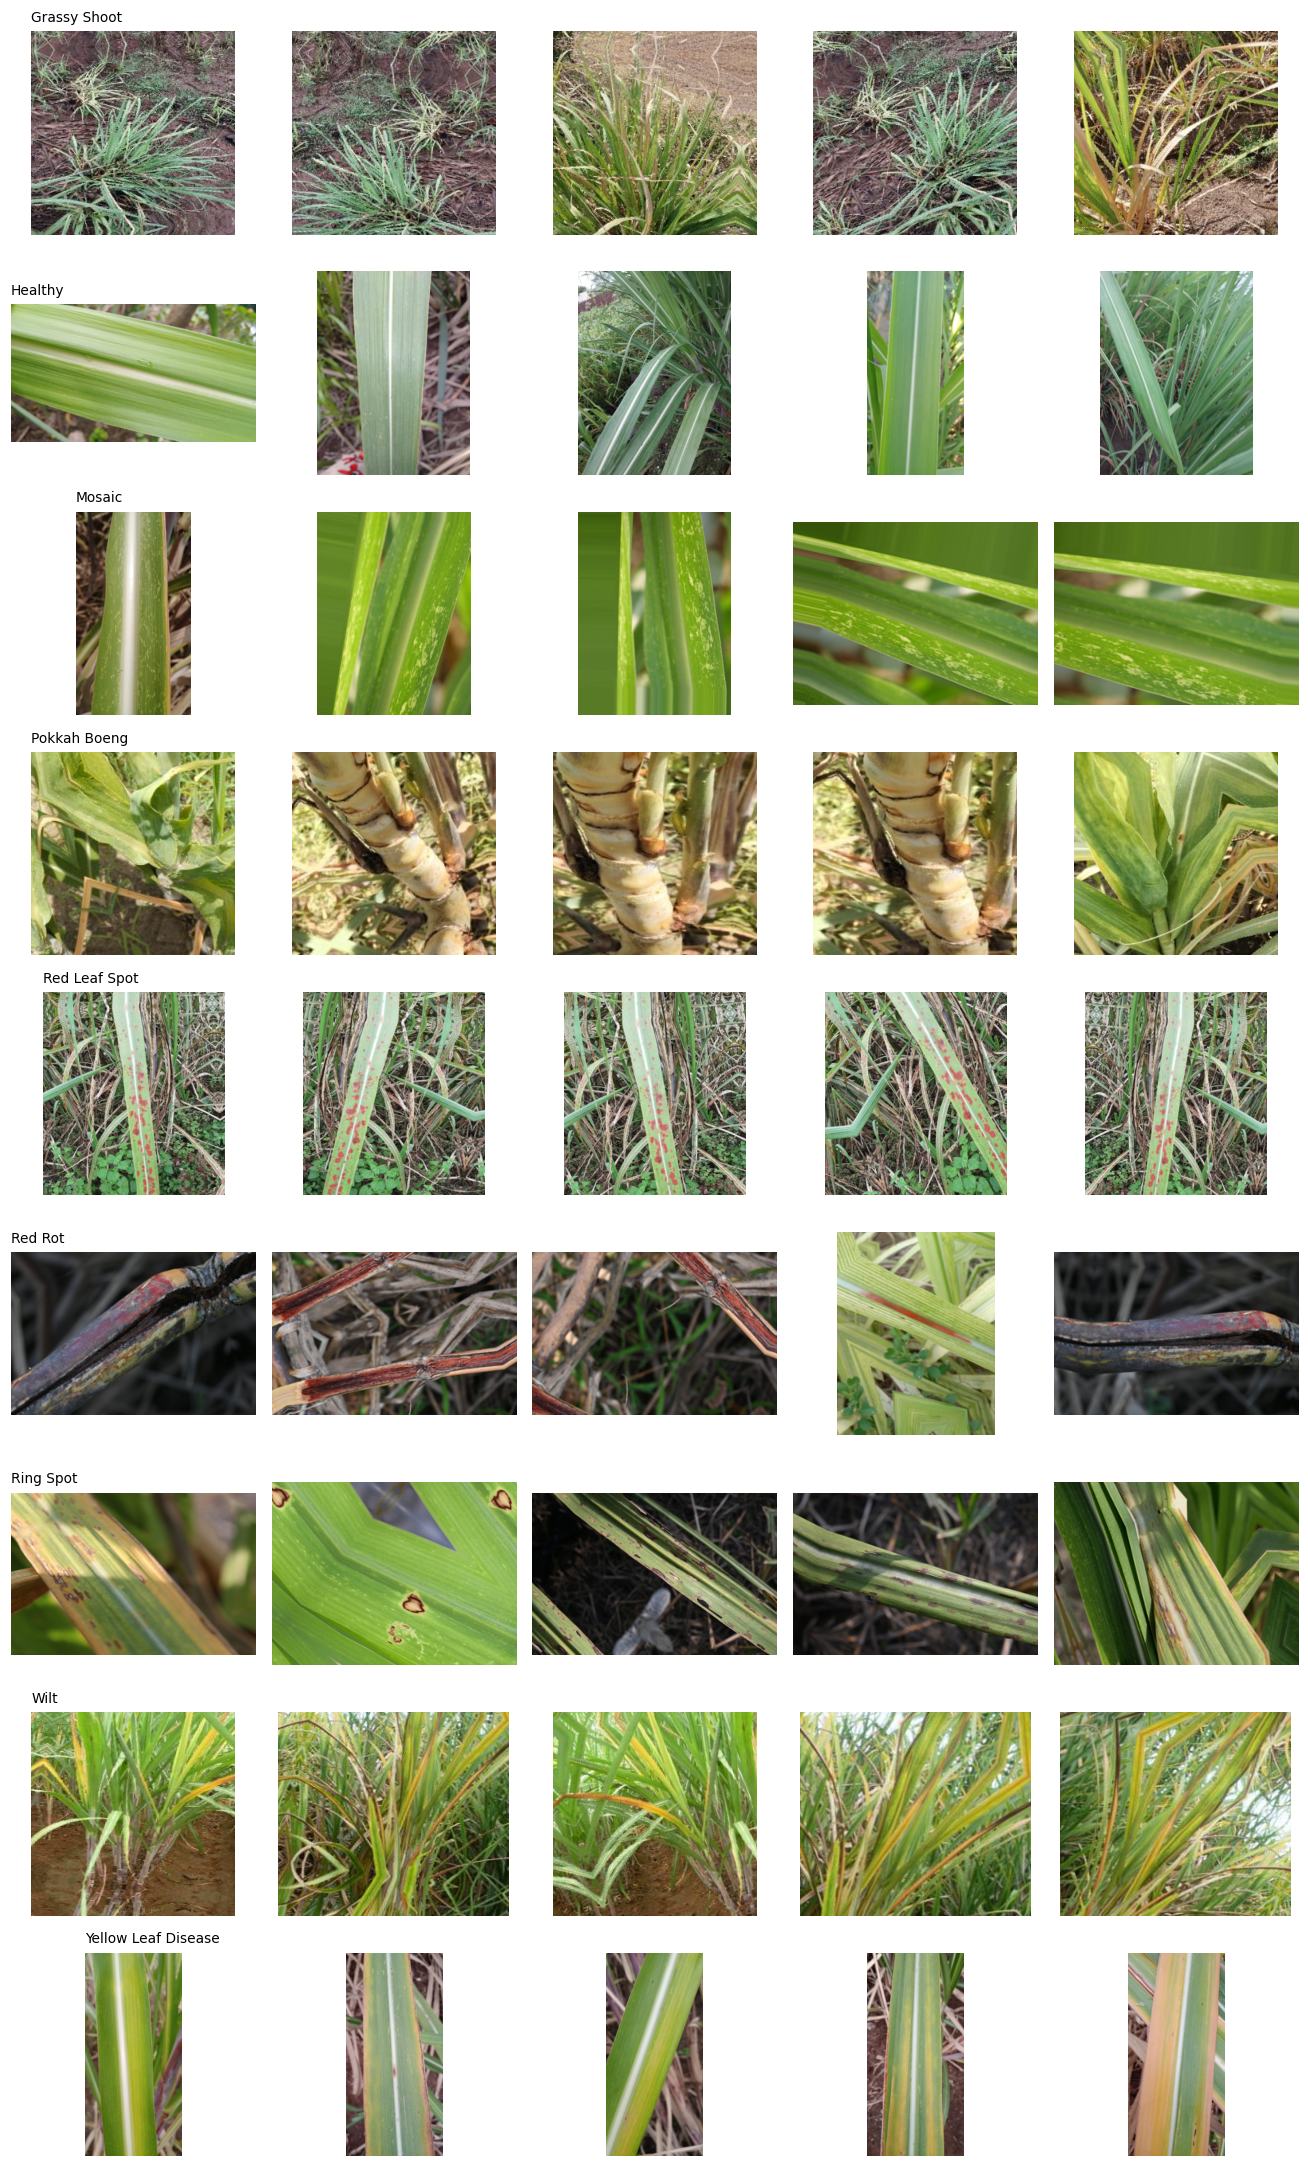

In [17]:
def load_rgb(path):
    im = Image.open(path); im = ImageOps.exif_transpose(im)      # honour phone-camera rotation
    return im.convert("RGB")

def show_samples(df, root, n=5, seed=CFG["SEED"]):
    rng = np.random.RandomState(seed)
    fig, axes = plt.subplots(len(CLASSES), n, figsize=(2.4 * n, 2.2 * len(CLASSES)))
    for i, c in enumerate(CLASSES):
        sub = df[df["class"] == c]
        pick = sub.iloc[rng.choice(len(sub), min(n, len(sub)), replace=False)]
        for j in range(n):
            ax = axes[i, j]; ax.axis("off")
            if j < len(pick):
                im = load_rgb(root / pick.iloc[j]["path"]); im.thumbnail((300, 300)); ax.imshow(im)
            if j == 0: ax.set_title(c, fontsize=9, loc="left")
    plt.tight_layout(); plt.savefig(ANALYSIS_DIR / "sample_images.png"); plt.show()
show_samples(manifest, DATASET_ROOT)

## Cell 10 — Image-quality checking (corruption, resolution, aspect ratio, duplicates)

checking images:   0%|          | 0/5769 [00:00<?, ?it/s]


Corrupted / unreadable images: 0

--- Resolution summary (pixels) ---
             w        h  megapixels       kb
count  5769.00  5769.00     5769.00  5769.00
mean   1784.89  1567.88        5.69   324.41
std    2056.36  1492.69        8.59   405.61
min     244.00   215.00        0.05    11.82
25%     256.00   256.00        0.07    22.67
50%     768.00  1040.00        0.61    69.32
75%    3858.00  3456.00       17.92   710.41
max    5568.00  5119.00       20.67  1696.44

Most common resolutions:
w     h   
256   256     1529
493   1040     611
1200  1346     611
5568  3712     570
5184  3888     529
768   1024     479
244   215      304
1040  493      114

Colour modes: {'RGB': 5769} | Decoded formats: {'JPEG': 5769}

Median resolution / file size per class (large differences between classes = possible shortcut for the model):
                          w       h      kb
class                                      
Grassy Shoot          256.0   256.0    23.0
Healthy               758.0 

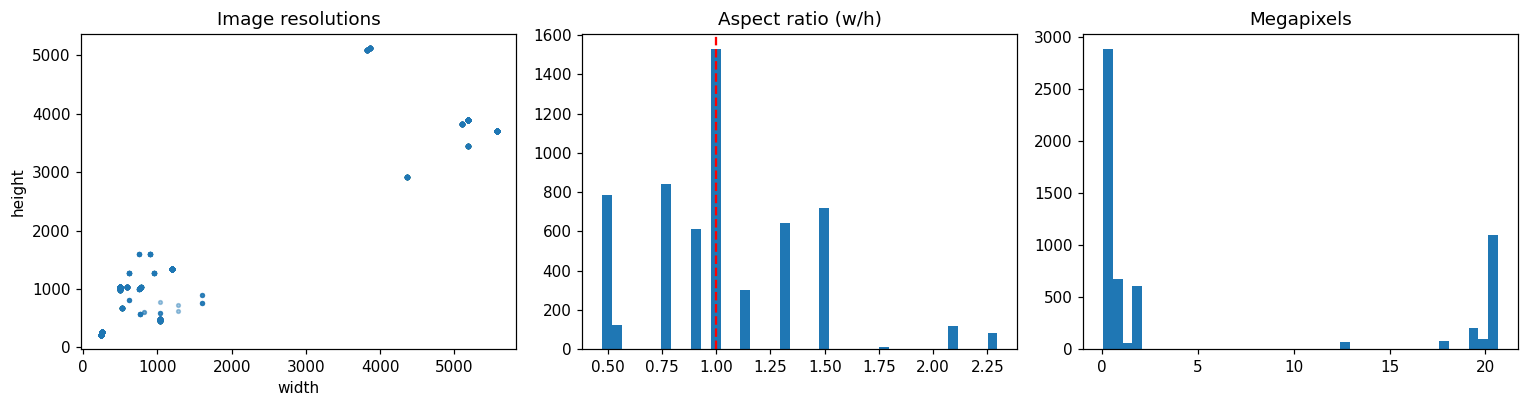


Non-square images: 73.5%  -> Resize(224,224) will stretch them (limitation noted).

Exact duplicate files: 1568 images in 572 duplicate groups; groups spanning >1 class (label conflicts): 0
Near-duplicate pairs (pHash Hamming <= 4): 1778  (heuristic: similar-looking leaves can also match; inspect before trusting)


In [18]:
def inspect_one(rel):
    p = DATASET_ROOT / rel
    out = dict(path=rel, ok=True, w=None, h=None, mode=None, fmt=None, kb=p.stat().st_size / 1024,
               md5=None, phash=None, err="")
    try:
        with open(p, "rb") as f: out["md5"] = hashlib.md5(f.read()).hexdigest()
        with Image.open(p) as im:
            im.verify()                                  # structural check
        with Image.open(p) as im:
            im.load(); out.update(w=im.width, h=im.height, mode=im.mode, fmt=im.format)   # full decode
            out["phash"] = str(imagehash.phash(ImageOps.exif_transpose(im).convert("RGB")))
    except Exception as e:
        out.update(ok=False, err=repr(e)[:150])
    return out

with ThreadPoolExecutor(max_workers=4) as ex:
    qrows = list(tqdm(ex.map(inspect_one, manifest["path"]), total=len(manifest), desc="checking images"))
quality = pd.DataFrame(qrows)
manifest = manifest.merge(quality.drop(columns=["ok", "err"]), on="path")
bad = quality[~quality["ok"]]
print(f"\nCorrupted / unreadable images: {len(bad)}")
if len(bad): print(bad[["path", "err"]].to_string())
bad.to_csv(ANALYSIS_DIR / "corrupted_images.csv", index=False)
manifest = manifest[manifest["path"].isin(quality[quality["ok"]]["path"])].reset_index(drop=True)

manifest["aspect"] = manifest["w"] / manifest["h"]
manifest["megapixels"] = manifest["w"] * manifest["h"] / 1e6
print("\n--- Resolution summary (pixels) ---");  print(manifest[["w", "h", "megapixels", "kb"]].describe().round(2).to_string())
print("\nMost common resolutions:"); print(manifest.groupby(["w", "h"]).size().sort_values(ascending=False).head(8).to_string())
print("\nColour modes:", dict(Counter(manifest["mode"])), "| Decoded formats:", dict(Counter(manifest["fmt"])))
print("\nMedian resolution / file size per class (large differences between classes = possible shortcut for the model):")
print(manifest.groupby("class")[["w", "h", "kb"]].median().round(0).to_string())

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].scatter(manifest["w"], manifest["h"], s=6, alpha=.4); ax[0].set_xlabel("width"); ax[0].set_ylabel("height"); ax[0].set_title("Image resolutions")
ax[1].hist(manifest["aspect"], bins=40); ax[1].set_title("Aspect ratio (w/h)"); ax[1].axvline(1, c="r", ls="--")
ax[2].hist(manifest["megapixels"], bins=40); ax[2].set_title("Megapixels")
plt.tight_layout(); plt.savefig(ANALYSIS_DIR / "resolution_analysis.png"); plt.show()
print(f"\nNon-square images: {(abs(manifest['aspect']-1) > 0.05).mean()*100:.1f}%  -> Resize(224,224) will stretch them (limitation noted).")

# --- exact duplicates
dup = manifest[manifest.duplicated("md5", keep=False)]
n_groups = dup["md5"].nunique()
cross = dup.groupby("md5")["class"].nunique(); cross = cross[cross > 1]
print(f"\nExact duplicate files: {len(dup)} images in {n_groups} duplicate groups; groups spanning >1 class (label conflicts): {len(cross)}")

# --- near duplicates (perceptual hash)
def hex_to_bits(h): return np.unpackbits(np.frombuffer(bytes.fromhex(h), dtype=np.uint8))
def near_dup_pairs(phashes, thr, chunk=256):
    bits = np.stack([hex_to_bits(h) for h in phashes]).astype(np.uint8)
    pairs = []
    for s in range(0, len(bits), chunk):
        d = (bits[s:s + chunk, None, :] != bits[None, :, :]).sum(-1)
        ii, jj = np.where(d <= thr)
        pairs += [(s + a, b) for a, b in zip(ii, jj) if s + a < b]
    return pairs
NEAR_PAIRS = near_dup_pairs(manifest["phash"].tolist(), CFG["NEAR_DUP_HAMMING"])
print(f"Near-duplicate pairs (pHash Hamming <= {CFG['NEAR_DUP_HAMMING']}): {len(NEAR_PAIRS)}  "
      "(heuristic: similar-looking leaves can also match; inspect before trusting)")
manifest.to_csv(ANALYSIS_DIR / "image_quality_table.csv", index=False)

## Cell 11 — Stratified split (70/15/15, seeded, leakage-aware, saved to disk)
Grouping logic: images that must not be separated (identical files, near-duplicates, or same id from an optional
filename regex) are merged into one *cluster*. If no clusters exist → plain exact stratified split. Otherwise →
`StratifiedGroupKFold` (stratified by class, whole clusters stay together; ratios then approximate 70/15/15).

**Field / plant IDs:** the Mendeley description says images come from 3 fields, but (from what I could verify)
it does not say the file names carry a field or plant ID. The cell below prints filename patterns so *you* can decide;
if names encode an ID, set `CFG["GROUP_REGEX"]`.

In [19]:
print("Example file names per class (look for field / plant / sequence identifiers):")
for c in CLASSES[:3]:
    print(" ", c, "->", [Path(p).name for p in manifest[manifest['class'] == c]["path"].head(4)])

class UnionFind:
    def __init__(s, n): s.p = list(range(n))
    def find(s, x):
        while s.p[x] != x: s.p[x] = s.p[s.p[x]]; x = s.p[x]
        return x
    def union(s, a, b): s.p[s.find(a)] = s.find(b)

def build_clusters(df, near_pairs):
    uf = UnionFind(len(df))
    if CFG["USE_EXACT_DUP_GROUPS"]:
        for _, idx in df.groupby("md5").indices.items():
            for k in idx[1:]: uf.union(idx[0], k)
    if CFG["USE_NEAR_DUP_GROUPS"]:
        for a, b in near_pairs: uf.union(a, b)
    if CFG["GROUP_REGEX"]:
        import re
        keys = df["path"].map(lambda p: (re.search(CFG["GROUP_REGEX"], Path(p).stem) or [None, None])[1])
        print(f"GROUP_REGEX matched {keys.notna().sum()}/{len(df)} files")
        tmp = df.assign(k=keys).reset_index(drop=True)
        for _, g in tmp.dropna(subset=["k"]).groupby("k"):
            ix = g.index.tolist()
            for k in ix[1:]: uf.union(ix[0], k)
    return np.array([uf.find(i) for i in range(len(df))])

def create_stratified_split(df, near_pairs):
    tr_r, va_r, te_r = CFG["SPLIT"]; seed = CFG["SEED"]
    assert abs(tr_r + va_r + te_r - 1) < 1e-6
    df = df.copy(); df["label"] = df["class"].map({c: i for i, c in enumerate(CLASSES)})
    df["cluster"] = build_clusters(df, near_pairs)
    sizes = df["cluster"].value_counts()
    n_multi = int((sizes > 1).sum())
    print(f"Clusters with >1 image: {n_multi} (largest = {sizes.max()} images)")
    if sizes.max() > 0.02 * len(df):
        print("WARNING: a very large cluster exists; near-duplicate threshold may be over-merging. Check before trusting.")
    if n_multi == 0:
        method = "train_test_split(stratify=label) - exact ratios"
        tr, tmp = train_test_split(df.index, test_size=va_r + te_r, stratify=df["label"], random_state=seed)
        va, te = train_test_split(tmp, test_size=te_r / (va_r + te_r), stratify=df.loc[tmp, "label"], random_state=seed)
    else:
        method = "StratifiedGroupKFold(cluster-aware) - ratios approximate"
        n_te = round(1 / te_r)
        s1 = StratifiedGroupKFold(n_splits=n_te, shuffle=True, random_state=seed)
        r, t = next(iter(s1.split(df, df["label"], df["cluster"])))
        rest, te = df.index[r], df.index[t]
        n_va = round(1 / (va_r / (1 - te_r)))
        s2 = StratifiedGroupKFold(n_splits=n_va, shuffle=True, random_state=seed)
        sub = df.loc[rest]
        r2, v2 = next(iter(s2.split(sub, sub["label"], sub["cluster"])))
        tr, va = sub.index[r2], sub.index[v2]
    df["split"] = ""
    df.loc[tr, "split"] = "train"; df.loc[va, "split"] = "val"; df.loc[te, "split"] = "test"
    print("Split method:", method)
    return df, method

MANIFEST_CSV = ANALYSIS_DIR / "split_manifest.csv"
def get_split(manifest, near_pairs):
    if MANIFEST_CSV.exists():
        old = pd.read_csv(MANIFEST_CSV)
        if set(old["path"]) == set(manifest["path"]):
            print(">>> Re-using SAVED split from", MANIFEST_CSV, "(same images stay in same subsets)")
            return old, "loaded from saved manifest"
        print("Saved manifest does not match current images -> creating a new split.")
    df, method = create_stratified_split(manifest, near_pairs)
    df.to_csv(MANIFEST_CSV, index=False)
    json.dump(dict(seed=CFG["SEED"], ratios=CFG["SPLIT"], method=method, classes=CLASSES,
                   near_dup_hamming=CFG["NEAR_DUP_HAMMING"], group_regex=CFG["GROUP_REGEX"],
                   counts=df["split"].value_counts().to_dict()), open(ANALYSIS_DIR / "split_config.json", "w"), indent=2)
    print("Saved:", MANIFEST_CSV)
    return df, method
split_df, SPLIT_METHOD = get_split(manifest, NEAR_PAIRS)
json.dump(CLASSES, open(ANALYSIS_DIR / "classes.json", "w"))

Example file names per class (look for field / plant / sequence identifiers):
  Grassy Shoot -> ['dup_0.jpeg', 'dup_1.jpeg', 'dup_10.jpeg', 'dup_100.jpeg']
  Healthy -> ['healthy_0001.jpeg', 'healthy_0003.jpeg', 'healthy_0004.jpeg', 'healthy_0005.jpeg']
  Mosaic -> ['mosaic_0001.jpeg', 'mosaic_0002.jpeg', 'mosaic_0003.jpeg', 'mosaic_0004.jpeg']
Clusters with >1 image: 635 (largest = 11 images)
Split method: StratifiedGroupKFold(cluster-aware) - ratios approximate
Saved: /content/sugarcane_xai/results/dataset_analysis/split_manifest.csv


## Cell 12 — Split verification (class balance per split + leakage audit)

Images per class per split:
 split                train  val  test
class                                
Grassy Shoot           435   86    90
Healthy                474  104   101
Mosaic                 436   88    87
Pokkah Boeng           439   85    87
Red Leaf Spot          432   92    87
Red Rot                485   96    97
Ring Spot              487   95    97
Wilt                   433   89    89
Yellow Leaf Disease    494   96    88
TOTAL                 4115  831   823

Class share (%) inside each split (should look alike):
 split                train    val   test
class                                   
Grassy Shoot         10.57  10.35  10.94
Healthy              11.52  12.52  12.27
Mosaic               10.60  10.59  10.57
Pokkah Boeng         10.67  10.23  10.57
Red Leaf Spot        10.50  11.07  10.57
Red Rot              11.79  11.55  11.79
Ring Spot            11.83  11.43  11.79
Wilt                 10.52  10.71  10.81
Yellow Leaf Disease  12.00  11.55  10.69

Split 

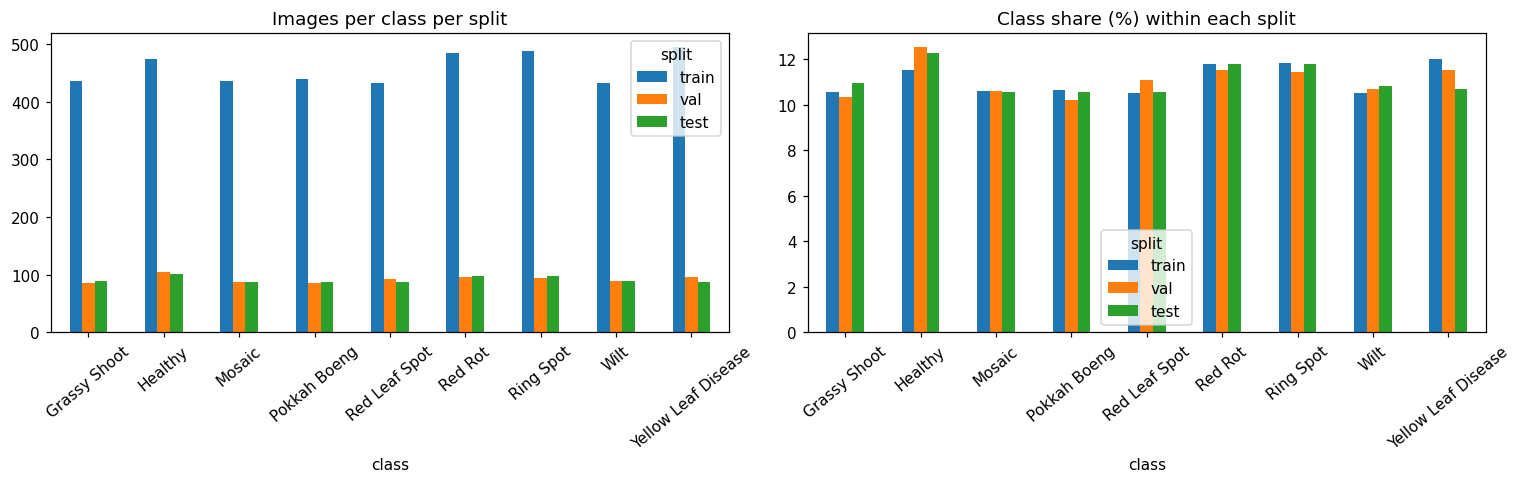


LEAKAGE AUDIT
  path overlap between splits      : 0 (asserted)
  identical-file (MD5) overlap     : 0
  near-duplicate pairs across splits: 0 (pHash <= 4; of 1778 total pairs)
  (0 expected when near-duplicate grouping is on)
  NOTE: no plant/field ID was used. If the 3 collection fields share visually similar backgrounds, test accuracy can still be optimistic; state this as a limitation.


In [20]:
def verify_split(df):
    ct = pd.crosstab(df["class"], df["split"])[["train", "val", "test"]]
    ct.loc["TOTAL"] = ct.sum()
    print("Images per class per split:\n", ct.to_string())
    pct = (100 * ct.drop("TOTAL") / ct.drop("TOTAL").sum()).round(2)
    print("\nClass share (%) inside each split (should look alike):\n", pct.to_string())
    print("\nSplit sizes (%):", (100 * df["split"].value_counts(normalize=True)).round(2).to_dict())
    print("Max class-share deviation between splits: %.2f percentage points" % (pct.max(axis=1) - pct.min(axis=1)).max())

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    ct.drop("TOTAL").plot.bar(ax=ax[0]); ax[0].set_title("Images per class per split"); ax[0].tick_params(axis="x", rotation=40)
    pct.plot.bar(ax=ax[1]); ax[1].set_title("Class share (%) within each split"); ax[1].tick_params(axis="x", rotation=40)
    plt.tight_layout(); plt.savefig(ANALYSIS_DIR / "split_distribution.png"); plt.show()

    # ---- leakage audit
    S = {s: set(df[df["split"] == s]["path"]) for s in ["train", "val", "test"]}
    assert not (S["train"] & S["val"] or S["train"] & S["test"] or S["val"] & S["test"]), "path overlap!"
    md = {s: set(df[df["split"] == s]["md5"]) for s in S}
    exact = len(md["train"] & md["val"]) + len(md["train"] & md["test"]) + len(md["val"] & md["test"])
    print(f"\nLEAKAGE AUDIT\n  path overlap between splits      : 0 (asserted)\n  identical-file (MD5) overlap     : {exact}")
    pairs = near_dup_pairs(df["phash"].tolist(), CFG["NEAR_DUP_HAMMING"])
    sp = df["split"].values
    cross = sum(sp[a] != sp[b] for a, b in pairs)
    print(f"  near-duplicate pairs across splits: {cross} (pHash <= {CFG['NEAR_DUP_HAMMING']}; of {len(pairs)} total pairs)")
    if "cluster" in df and CFG["USE_NEAR_DUP_GROUPS"]:
        print("  (0 expected when near-duplicate grouping is on)")
    if CFG["GROUP_REGEX"] is None:
        print("  NOTE: no plant/field ID was used. If the 3 collection fields share visually similar backgrounds, "
              "test accuracy can still be optimistic; state this as a limitation.")
    return ct
split_table = verify_split(split_df)
split_table.to_csv(ANALYSIS_DIR / "split_class_counts.csv")

## Cell 13 — Preprocessing (224×224, ImageNet normalisation) — from synopsis
* `Resize(224,224)`: matches ConvNeXt V2-Tiny pretrained input size (224).
* `Normalize(ImageNet mean/std)`: pretrained weights expect this input distribution.

In [21]:
import torch, cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
IMG = CFG["IMG_SIZE"]
IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

def create_transforms():
    norm = [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
    base = [A.Resize(height=IMG, width=IMG, interpolation=cv2.INTER_AREA)]
    # ---- Cell 14 content (augmentation) ----
    train_aug = [
        A.HorizontalFlip(p=0.5),                                                        # ADDITIONAL (not in synopsis)
        A.Affine(rotate=(-30, 30), scale=(0.85, 1.15), border_mode=cv2.BORDER_REFLECT_101, p=0.8),  # SYNOPSIS: rotation + scaling
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02, p=0.8),   # SYNOPSIS: colour jitter (hue kept tiny)
    ]
    return (A.Compose(base + train_aug + norm), A.Compose(base + norm), A.Compose(base + norm))

train_tf, val_tf, test_tf = create_transforms()
print("VAL/TEST transforms (deterministic):"); print(val_tf)

VAL/TEST transforms (deterministic):
Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=3, mask_interpolation=0, width=224),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


## Cell 14 — Augmentation (what is used and why)
| Transform | Source | Why |
|---|---|---|
| Affine rotation ±30° | **Synopsis** | leaves are photographed at arbitrary angles |
| Affine scale 0.85–1.15 | **Synopsis** | changes in camera distance / lesion size |
| ColorJitter b/c/s 0.2, **hue only 0.02** | **Synopsis** | lighting variation; hue is kept tiny because leaf *colour* (yellowing, browning) is itself diagnostic |
| HorizontalFlip 0.5 | *Additional recommendation* | leaf orientation has no diagnostic meaning |

Validation and test use **no** random augmentation. Note: augmentation is applied on-the-fly to the training set only;
it never creates files, so it cannot leak across splits.

In [22]:
print("TRAIN transforms (random):"); print(train_tf)

TRAIN transforms (random):
Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=3, mask_interpolation=0, width=224),
  HorizontalFlip(p=0.5),
  Affine(p=0.8, balanced_scale=False, border_mode=4, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(-30.0, 30.0), rotate_method='largest_box', scale={'x': (0.85, 1.15), 'y': (0.85, 1.15)}, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, translate_percent=None, translate_px={'x': (0, 0), 'y': (0, 0)}),
  ColorJitter(p=0.8, brightness=(0.8, 1.2), contrast=(0.8, 1.2), hue=(-0.02, 0.02), saturation=(0.8, 1.2)),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


## Cell 15 — Dataset / DataLoader creation

In [23]:
class SugarcaneDataset(Dataset):
    def __init__(self, df, root, transform):
        self.df, self.root, self.tf = df.reset_index(drop=True), Path(root), transform
        self.paths, self.labels = self.df["path"].tolist(), self.df["label"].astype(int).tolist()
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        img = np.array(load_rgb(self.root / self.paths[i]))
        return self.tf(image=img)["image"], self.labels[i], i

def create_dataloaders(split_df):
    from torch.utils.data import WeightedRandomSampler
    dfs = {s: split_df[split_df["split"] == s] for s in ["train", "val", "test"]}
    dss = {"train": SugarcaneDataset(dfs["train"], DATASET_ROOT, train_tf),
           "val": SugarcaneDataset(dfs["val"], DATASET_ROOT, val_tf),
           "test": SugarcaneDataset(dfs["test"], DATASET_ROOT, test_tf)}
    g = torch.Generator(); g.manual_seed(CFG["SEED"])
    def wif(worker_id):
        s = CFG["SEED"] + worker_id; np.random.seed(s); random.seed(s)
    kw = dict(batch_size=CFG["BATCH_SIZE"], num_workers=CFG["NUM_WORKERS"], pin_memory=torch.cuda.is_available(),
              worker_init_fn=wif, generator=g, persistent_workers=CFG["NUM_WORKERS"] > 0)
    if CFG["USE_WEIGHTED_SAMPLER"]:
        cnt = np.bincount(dss["train"].labels, minlength=len(CLASSES)); w = 1.0 / cnt[dss["train"].labels]
        sampler = WeightedRandomSampler(w, len(w), replacement=True, generator=g)
        train_dl = DataLoader(dss["train"], sampler=sampler, drop_last=True, **kw)
    else:
        train_dl = DataLoader(dss["train"], shuffle=True, drop_last=True, **kw)
    loaders = {"train": train_dl,
               "val": DataLoader(dss["val"], shuffle=False, **kw),
               "test": DataLoader(dss["test"], shuffle=False, **kw)}
    return dss, loaders

datasets, loaders = create_dataloaders(split_df)
xb, yb, ib = next(iter(loaders["train"]))
print("One training batch:", tuple(xb.shape), xb.dtype, "| labels:", yb[:8].tolist())
print(f"pixel range after normalisation: min={xb.min():.2f} max={xb.max():.2f} mean={xb.mean():.3f} std={xb.std():.3f}")

One training batch: (32, 3, 224, 224) torch.float32 | labels: [2, 6, 7, 0, 4, 8, 7, 8]
pixel range after normalisation: min=-2.12 max=2.64 mean=-0.038 std=0.913


## Cell 16 — Augmentation visualisation

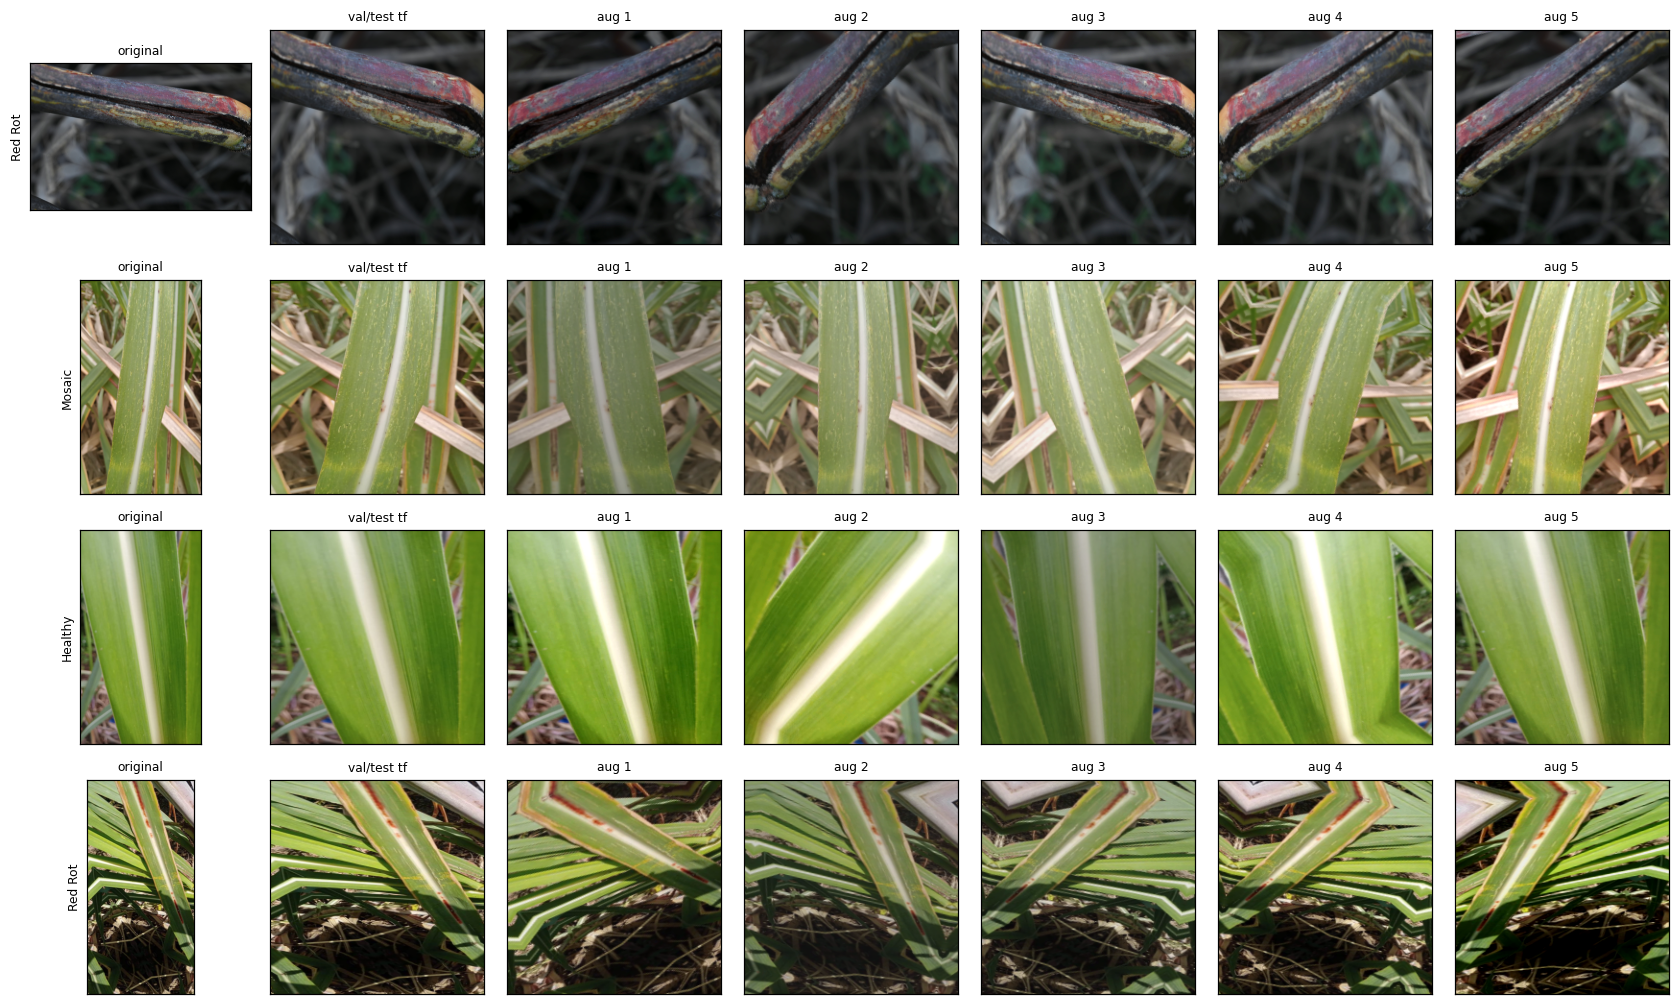

In [24]:
def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1); s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.cpu() * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

def show_augmentations(n_images=4, n_aug=5):
    tr = datasets["train"]; rng = np.random.RandomState(CFG["SEED"])
    picks = rng.choice(len(tr), n_images, replace=False)
    fig, axes = plt.subplots(n_images, n_aug + 2, figsize=(2.2 * (n_aug + 2), 2.3 * n_images))
    for r, i in enumerate(picks):
        raw = np.array(load_rgb(tr.root / tr.paths[i]))
        axes[r, 0].imshow(raw); axes[r, 0].set_title("original", fontsize=8)
        axes[r, 1].imshow(denorm(val_tf(image=raw)["image"])); axes[r, 1].set_title("val/test tf", fontsize=8)
        for k in range(n_aug):
            axes[r, k + 2].imshow(denorm(train_tf(image=raw)["image"])); axes[r, k + 2].set_title(f"aug {k+1}", fontsize=8)
        axes[r, 0].set_ylabel(CLASSES[tr.labels[i]], fontsize=8)
        for a in axes[r]: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.savefig(ANALYSIS_DIR / "augmentation_examples.png"); plt.show()
show_augmentations()

## Cell 16b — Final summary of the dataset pipeline

In [25]:
print("=" * 70, "\nDATASET PIPELINE SUMMARY\n" + "=" * 70)
print("Dataset root      :", DATASET_ROOT)
print("Classes (%d)      :" % len(CLASSES), CLASSES)
print("Images analysed   :", len(manifest), "| corrupted removed:", len(bad))
print("Split method      :", SPLIT_METHOD, "| seed:", CFG["SEED"])
for s in ["train", "val", "test"]:
    n = len(datasets[s]); print(f"  {s:5s}: {n:5d} images | {len(loaders[s])} batches of {CFG['BATCH_SIZE']}")
print("Input             : %dx%d, ImageNet mean/std" % (IMG, IMG))
print("Train augmentation: rotation, scaling, colour jitter (synopsis) + horizontal flip (additional)")
print("Saved files       :", sorted(p.name for p in ANALYSIS_DIR.iterdir()))
print("\nNext: verify the tables/plots above, then continue with the model notebook (same Cells 1-16 + 17-32).")

DATASET PIPELINE SUMMARY
Dataset root      : /content/sugarcane_data/Sugarcane Plant Disease Dataset of Assam
Classes (9)      : ['Grassy Shoot', 'Healthy', 'Mosaic', 'Pokkah Boeng', 'Red Leaf Spot', 'Red Rot', 'Ring Spot', 'Wilt', 'Yellow Leaf Disease']
Images analysed   : 5769 | corrupted removed: 0
Split method      : StratifiedGroupKFold(cluster-aware) - ratios approximate | seed: 42
  train:  4115 images | 128 batches of 32
  val  :   831 images | 26 batches of 32
  test :   823 images | 26 batches of 32
Input             : 224x224, ImageNet mean/std
Train augmentation: rotation, scaling, colour jitter (synopsis) + horizontal flip (additional)
Saved files       : ['augmentation_examples.png', 'class_counts.csv', 'class_distribution.png', 'classes.json', 'corrupted_images.csv', 'image_quality_table.csv', 'resolution_analysis.png', 'sample_images.png', 'split_class_counts.csv', 'split_config.json', 'split_distribution.png', 'split_manifest.csv']

Next: verify the tables/plots above,